# Urban Mobility & Economic Productivity in Latin America
## Análisis de movilidad urbana y productividad económica con Python

**Proyecto de análisis de datos | Sergio Yépez**

Este proyecto analiza la relación entre indicadores de movilidad urbana y productividad económica, integrando datos de **TomTom Traffic Index** y **OECD Cities**. El análisis se concentra en **2024** y busca identificar patrones de congestión, diferencias entre ciudades y posibles oportunidades para orientar decisiones de infraestructura y movilidad.


### Herramientas y técnicas

- Python
- Pandas y NumPy
- Matplotlib y Seaborn
- Limpieza y transformación de datos
- Agregación por ciudad y año
- Integración de datasets mediante `merge`
- Análisis exploratorio y visualización


## 1. Descripción del proyecto

El objetivo es evaluar cómo la movilidad urbana se relaciona con indicadores de productividad económica. Para ello se preparan, limpian e integran dos fuentes de datos: información de tráfico de TomTom e indicadores económicos urbanos de OECD Cities.

El flujo de trabajo comprende exploración, estandarización, transformación de tipos, filtrado temporal, agregación de métricas de tráfico, integración de fuentes, visualización y elaboración de conclusiones.


## 2. Carga y exploración de datos

Se importan las librerías necesarias y se cargan los datasets de tráfico y economía. A continuación se revisan estructura, columnas, tipos de datos y posibles inconsistencias antes de iniciar las transformaciones.


In [1]:
# Ejecuta esto en una celda:
from IPython.display import clear_output
clear_output(wait=True)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datasets
traffic = pd.read_csv("/datasets/tomtom_traffic.csv")
eco = pd.read_csv("/datasets/oecd_city_economy.csv")

# Vista rápida
print("=== TRAFFIC (TomTom) ===")
print(traffic.head(), "\n")

print("=== ECONOMÍA (OECD Cities) ===")
print(eco.head())

=== TRAFFIC (TomTom) ===
  Country       City            UpdateTimeUTC  JamsDelay  TrafficIndexLive  \
0     ARE  abu-dhabi  2025-01-13 04:01:30.001      650.7              36.0   
1     ARE  abu-dhabi  2025-01-13 03:46:00.000      540.4              30.0   
2     ARE  abu-dhabi  2025-01-13 02:46:30.000       71.8               7.0   
3     ARE  abu-dhabi  2025-01-13 01:46:30.001        8.2               2.0   
4     ARE  abu-dhabi  2025-01-13 00:01:30.000        1.1               1.0   

   JamsLengthInKms  JamsCount  TrafficIndexWeekAgo     UpdateTimeUTCWeekAgo  \
0            109.1      162.0                 30.0  2025-01-06 04:01:30.000   
1            101.4      136.0                 27.0  2025-01-06 03:46:30.001   
2             18.9       23.0                  6.0  2025-01-06 02:46:30.000   
3              4.1        2.0                  2.0  2025-01-06 01:46:30.000   
4              0.2        1.0                  1.0  2025-01-06 00:01:30.000   

   TravelTimeLivePer10KmsMins  


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [3]:
# Examinar la estructura de traffic
print("=== INFO: TRAFFIC ===")
traffic.info()
print("\nPrimeras 3 filas:")
display(traffic.head(3))

=== INFO: TRAFFIC ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 n

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


In [4]:
# Examinar la estructura de eco
print("\n=== INFO: ECONOMÍA (OECD) ===")
eco.info()
print("\nPrimeras 3 filas:")
display(eco.head(3))


=== INFO: ECONOMÍA (OECD) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB

Primeras 3 filas:


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


## 📊 Análisis del Dataset Traffic (TomTom)

### Estructura identificada:
- **Filas:** 1,004,464 registros
- **Columnas:** 12 columnas
- **Valores nulos:** ✅ No hay valores faltantes

### Tipos de datos identificados:
- **Correctos:** 8 columnas numéricas (float64) ya están bien
- **Requieren conversión:** 2 columnas de fecha están como 'object'

### Columnas que necesitan conversión:
| Columna | Tipo Actual | Problema | Tipo Ideal |
|---------|-------------|----------|------------|
| UpdateTimeUTC | object | Fecha como string | datetime64 |
| UpdateTimeUTCWeekAgo | object | Fecha como string | datetime64 |

### Conclusión:
El dataset traffic está estructuralmente limpio, solo requiere convertir las fechas a formato datetime para análisis temporal.

## 📊 Análisis del Dataset Economía (OECD)

### Estructura identificada:
- **Filas:** 30 registros
- **Columnas:** 7 columnas  
- **Valores nulos:** ✅ No hay valores faltantes

### Tipos de datos identificados:
- **Correctos:** Year (int64) ✅
- **Requieren conversión:** 4 columnas numéricas están como 'object'

### Columnas que necesitan conversión:
| Columna | Tipo Actual | Problema | Tipo Ideal |
|---------|-------------|----------|------------|
| City GDP/capita | object | Formato europeo "15.782,00" | float64 |
| Unemployment % | object | Contiene símbolo "%" | float64 |
| PM2.5 (μg/m³) | object | Coma decimal "15,2" | float64 |
| Population (M) | object | Coma decimal "15,30" | float64 |

### Conclusión:
El dataset eco requiere limpieza significativa: convertir formato europeo a formato numérico estándar y remover símbolos especiales.

### 3.1 Estandarización de nombres de columnas

Los nombres de columnas se normalizan a formato `snake_case` para facilitar su manipulación y reducir inconsistencias durante las transformaciones y la integración de datos.


In [5]:
# Renombrar todas las columnas al formato snake_case para traffic.

traffic = traffic.rename(columns={
    'Country': 'country',
    'City': 'city', 
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_in_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_per_10kms_mins',
    'MinsDelay': 'mins_delay'
})

In [6]:
# Verificar que los cambios se hayan aplicado correctamente
print("Columnas después del renombrado:")
print(traffic.columns.tolist())

Columnas después del renombrado:
['country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live', 'jams_length_in_kms', 'jams_count', 'traffic_index_week_ago', 'update_time_utc_week_ago', 'travel_time_live_per_10kms_mins', 'travel_time_historic_per_10kms_mins', 'mins_delay']


### 3.2 Corrección de formatos numéricos y temporales

Las columnas de fecha se convierten a `datetime` con manejo de errores. En el dataset económico se normalizan separadores decimales, símbolos de porcentaje y campos numéricos. También se genera una variable de población total a partir de la población expresada en millones.


In [7]:
# Revisar las columnas de fecha en el dataset traffic

print("=== DATASET TRAFFIC - COLUMNAS DE FECHA ===")
print("\nTipos de datos de las columnas de fecha:")
print(f"update_time_utc: {traffic['update_time_utc'].dtype}")
print(f"update_time_utc_week_ago: {traffic['update_time_utc_week_ago'].dtype}")

print("\nPrimeros 5 valores de update_time_utc:")
print(traffic['update_time_utc'].head())

print("\nPrimeros 5 valores de update_time_utc_week_ago:")
print(traffic['update_time_utc_week_ago'].head())

=== DATASET TRAFFIC - COLUMNAS DE FECHA ===

Tipos de datos de las columnas de fecha:
update_time_utc: object
update_time_utc_week_ago: object

Primeros 5 valores de update_time_utc:
0    2025-01-13 04:01:30.001
1    2025-01-13 03:46:00.000
2    2025-01-13 02:46:30.000
3    2025-01-13 01:46:30.001
4    2025-01-13 00:01:30.000
Name: update_time_utc, dtype: object

Primeros 5 valores de update_time_utc_week_ago:
0    2025-01-06 04:01:30.000
1    2025-01-06 03:46:30.001
2    2025-01-06 02:46:30.000
3    2025-01-06 01:46:30.000
4    2025-01-06 00:01:30.000
Name: update_time_utc_week_ago, dtype: object


In [8]:
# Revisar las columnas numéricas en el dataset eco (con nombres correctos)

print("\n=== DATASET ECO - COLUMNAS NUMÉRICAS ===")
print("\nTipos de datos de las columnas numéricas:")
print(f"City GDP/capita: {eco['City GDP/capita'].dtype}")
print(f"Unemployment %: {eco['Unemployment %'].dtype}")
print(f"Population (M): {eco['Population (M)'].dtype}")

print("\nPrimeros 5 valores de City GDP/capita:")
print(eco['City GDP/capita'].head())

print("\nPrimeros 5 valores de Unemployment %:")
print(eco['Unemployment %'].head())

print("\nPrimeros 5 valores de Population (M):")
print(eco['Population (M)'].head())


=== DATASET ECO - COLUMNAS NUMÉRICAS ===

Tipos de datos de las columnas numéricas:
City GDP/capita: object
Unemployment %: object
Population (M): object

Primeros 5 valores de City GDP/capita:
0    15.782,00
1    14.475,00
2    13.142,00
3    15.999,00
4     8.761,00
Name: City GDP/capita, dtype: object

Primeros 5 valores de Unemployment %:
0     6.2%
1     9.1%
2     9.8%
3     8.3%
4    13.1%
Name: Unemployment %, dtype: object

Primeros 5 valores de Population (M):
0    15,30
1    22,50
2    13,60
3     4,70
4     3,90
Name: Population (M), dtype: object


In [9]:
# ======================================
# CORREGIR FORMATO DE FECHAS EN TRAFFIC
# ======================================

# Convertir columnas de fecha a datetime con manejo de errores
traffic["update_time_utc"] = pd.to_datetime(traffic["update_time_utc"], errors="coerce")
traffic["update_time_utc_week_ago"] = pd.to_datetime(traffic["update_time_utc_week_ago"], errors="coerce")

print("Fechas convertidas correctamente (traffic):")
print(traffic[["update_time_utc", "update_time_utc_week_ago"]].head())

Fechas convertidas correctamente (traffic):
          update_time_utc update_time_utc_week_ago
0 2025-01-13 04:01:30.001  2025-01-06 04:01:30.000
1 2025-01-13 03:46:00.000  2025-01-06 03:46:30.001
2 2025-01-13 02:46:30.000  2025-01-06 02:46:30.000
3 2025-01-13 01:46:30.001  2025-01-06 01:46:30.000
4 2025-01-13 00:01:30.000  2025-01-06 00:01:30.000


In [10]:
# Renombrar todas las columnas al formato snake_case para eco.

eco = eco.rename(columns={
    "City": "city",
    "Country": "country",
    "Year": "year",
    "City GDP/capita": "gdp_per_capita",
    "Unemployment %": "unemployment_rate",
    "PM2.5 (μg/m³)": "pm25",
    "Population (M)": "population_m"
})

In [11]:
# ==============================
# LIMPIEZA DE VALORES NUMÉRICOS
# ==============================

eco["gdp_per_capita"] = (
    eco["gdp_per_capita"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

eco["unemployment_rate"] = (
    eco["unemployment_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

eco["population_m"] = (
    eco["population_m"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

In [12]:
# ================================
# CREANDO LA COLUMNA "POPULATION"
# ================================

eco["population"] = eco["population_m"] * 1_000_000

In [13]:
# =============
# VERIFICACIÓN
# =============

print(sorted(eco.columns))
print(eco.info())
print(eco.head())

['city', 'country', 'gdp_per_capita', 'pm25', 'population', 'population_m', 'unemployment_rate', 'year']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               30 non-null     int64  
 1   city               30 non-null     object 
 2   country            30 non-null     object 
 3   gdp_per_capita     30 non-null     float64
 4   unemployment_rate  30 non-null     float64
 5   pm25               30 non-null     object 
 6   population_m       30 non-null     float64
 7   population         30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB
None
   year            city    country  gdp_per_capita  unemployment_rate   pm25  \
0  2023    buenos-aires  Argentina         15782.0                6.2   15,2   
1  2023       sao-paulo     Brazil         14475.0                9.1  29,50   
2  202

## 4. Selección del período de análisis: 2024

A partir de la fecha de actualización del dataset de tráfico se crea la variable `year`. Ambos datasets se filtran al año **2024** para trabajar con un período común y comparable.


In [14]:
# ===============================
#CREANDO COLUMNA year EN TRAFFIC
# ===============================

traffic['year'] = traffic['update_time_utc'].dt.year

In [15]:
# =====================================
# FILTRANDO AMBOS DATASETS AL AÑO 2024
# =====================================

traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

In [17]:
traffic_2024.shape, eco_2024.shape

((886779, 13), (15, 8))

In [19]:
# ============
# VERIFICANDO
# ============

traffic_2024['year'].unique()
eco_2024['year'].unique()

array([2024])

## 5. Agregación de métricas de movilidad

El dataset de tráfico contiene múltiples observaciones por ciudad. Para obtener una vista consolidada, las métricas relevantes se agrupan por `city`, `country` y `year`, calculando sus promedios para 2024.


In [20]:
# ================================
# DEFINIENDO MÉTRICAS RELEVANTES
# ================================
metricas = [
    "jams_delay",
    "traffic_index_live",
    "jams_length_in_kms",   
    "jams_count",
    "mins_delay",
    "travel_time_live_per_10kms_mins",
    "travel_time_historic_per_10kms_mins" 
]

# ==========================================
# VALIDANDO COLUMNAS EXISTENTES DE VERDAD
# ==========================================
metricas_existentes = [col for col in metricas if col in traffic_2024.columns]

print("\n🔍 MÉTRICAS SOLICITADAS:", metricas)
print("✅ MÉTRICAS ENCONTRADAS EN traffic_2024:", metricas_existentes)

# Validación fuerte
if len(metricas_existentes) == 0:
    raise ValueError("❌ Ninguna de las métricas existe en traffic_2024. Revisa nombres de columnas.")

# =============================================================
# AGRUPANDO POR CIUDAD, PAÍS, AÑO Y CALCULAR PROMEDIOS 2024
# =============================================================
traffic_city_year_2024 = (
    traffic_2024
    .groupby(["city", "country", "year"])[metricas_existentes]
    .mean()
    .reset_index()
)

# ================================
# PRINT DE RESULTADOS
# ================================
print("\n🎉 **PROMEDIOS POR CIUDAD - 2024 GENERADOS EXITOSAMENTE** 🎉")
print(f"🏙️ Número de ciudades procesadas: {traffic_city_year_2024.shape[0]}")
print(f"📊 Número de columnas: {traffic_city_year_2024.shape[1]}")

print("\n✨ Vista previa del resultado (primeras 5 filas):")
print(traffic_city_year_2024.head())

# Resumen final
print("\n📌 RESUMEN GENERAL DEL DATASET RESULTANTE:")
print(traffic_city_year_2024.describe(include='all'))


🔍 MÉTRICAS SOLICITADAS: ['jams_delay', 'traffic_index_live', 'jams_length_in_kms', 'jams_count', 'mins_delay', 'travel_time_live_per_10kms_mins', 'travel_time_historic_per_10kms_mins']
✅ MÉTRICAS ENCONTRADAS EN traffic_2024: ['jams_delay', 'traffic_index_live', 'jams_length_in_kms', 'jams_count', 'mins_delay', 'travel_time_live_per_10kms_mins', 'travel_time_historic_per_10kms_mins']

🎉 **PROMEDIOS POR CIUDAD - 2024 GENERADOS EXITOSAMENTE** 🎉
🏙️ Número de ciudades procesadas: 387
📊 Número de columnas: 10

✨ Vista previa del resultado (primeras 5 filas):
        city country  year  jams_delay  traffic_index_live  \
0   a-coruna     ESP  2024   17.935187           15.259774   
1     aachen     DEU  2024   26.732141           20.960314   
2     aarhus     DNK  2024   21.200616           16.575891   
3  abu-dhabi     ARE  2024  171.157315           13.902028   
4      adana     TUR  2024   83.864761           22.541040   

   jams_length_in_kms  jams_count  mins_delay  \
0            2.198

In [21]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


### Hallazgo destacado

En el dataset de tráfico agregado para 2024, **Mexico City** presenta el mayor `jams_delay` promedio, con aproximadamente **2,833.06**. Este resultado la posiciona como un caso especialmente relevante para profundizar en el análisis de congestión urbana.


## 6. Integración de movilidad y economía

Se seleccionan las variables disponibles y relevantes de ambos datasets y se realiza una unión `INNER` mediante las claves `city` y `year`. De esta forma, el análisis final conserva únicamente las ciudades con información coincidente de movilidad y economía en 2024.


In [22]:
# Definimos las columnas que queremos (pero solo tomamos las que existan)

traffic_cols = ["city", "year", "jams_delay", "congestion", "traffic_index"]
eco_cols = ["city", "year", "gdp_per_capita", "population", "region"]

traffic_existing = [c for c in traffic_cols if c in traffic_city_year_2024.columns]
eco_existing = [c for c in eco_cols if c in eco_2024.columns]

traffic_subset = traffic_city_year_2024[traffic_existing].copy()
eco_subset = eco_2024[eco_existing].copy()

# Hacemos el merge INNER
merged = traffic_subset.merge(
    eco_subset,
    on=["city", "year"],
    how="inner"
)

print("🔥 MERGE COMPLETADO ✔\n")
print(merged.head())

🔥 MERGE COMPLETADO ✔

             city  year   jams_delay  gdp_per_capita  population
0  belo-horizonte  2024   263.047879         11124.0   6100000.0
1          bogota  2024  1141.552364         11442.0  11300000.0
2        brasilia  2024   101.576326         16251.0   4800000.0
3    buenos-aires  2024   571.089593         18117.0  15400000.0
4        curitiba  2024   183.469274         12381.0   3700000.0


In [23]:
# Resumen del dataset integrado
print(f"📊 Total de ciudades en el merge: {merged.shape[0]}")
print(f"📈 Columnas disponibles: {list(merged.columns)}")
print(f"\n🌍 Países representados:")
print(merged.groupby('city').size())

📊 Total de ciudades en el merge: 15
📈 Columnas disponibles: ['city', 'year', 'jams_delay', 'gdp_per_capita', 'population']

🌍 Países representados:
city
belo-horizonte    1
bogota            1
brasilia          1
buenos-aires      1
curitiba          1
fortaleza         1
lima              1
mexico-city       1
montevideo        1
porto-alegre      1
recife            1
rio-de-janeiro    1
salvador          1
santiago          1
sao-paulo         1
dtype: int64


## 7. Visualización y análisis exploratorio

Se utilizan visualizaciones para estudiar la distribución del retraso por tráfico (`jams_delay`), la distribución del PIB per cápita y la comparación entre ambas variables por ciudad. El objetivo es detectar dispersión, valores atípicos y patrones generales que ayuden a interpretar la relación entre movilidad y desempeño económico.


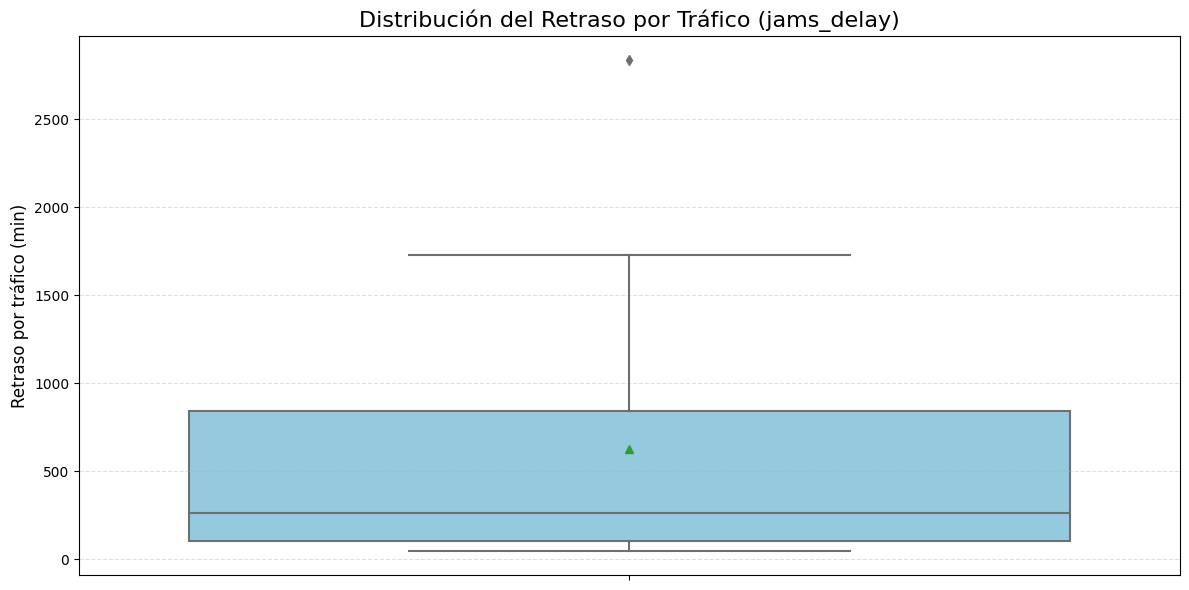

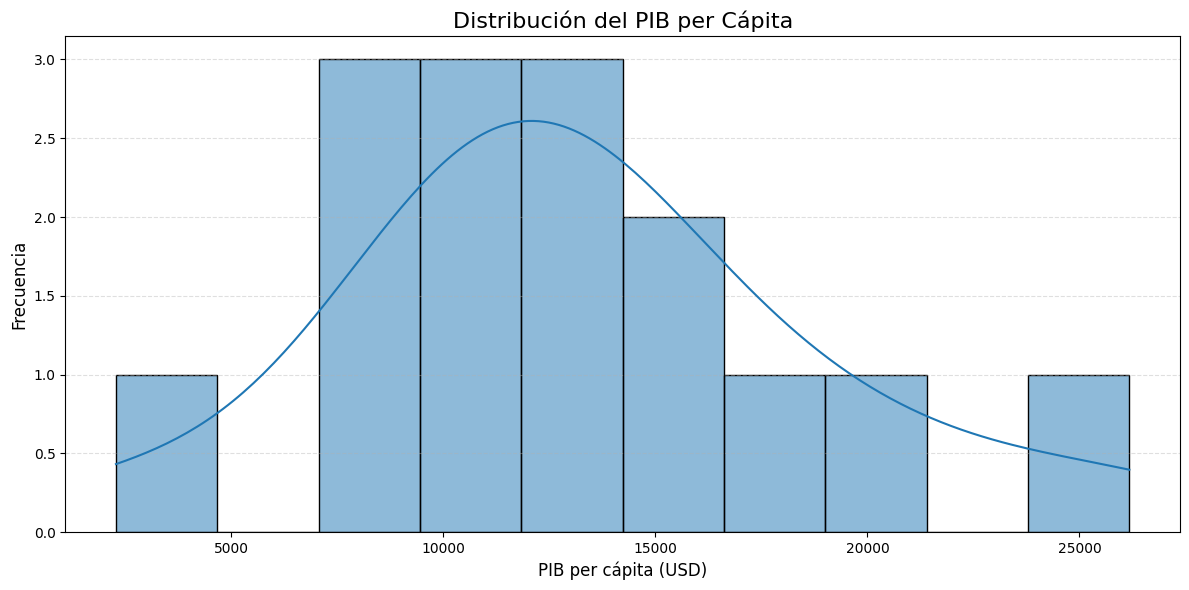

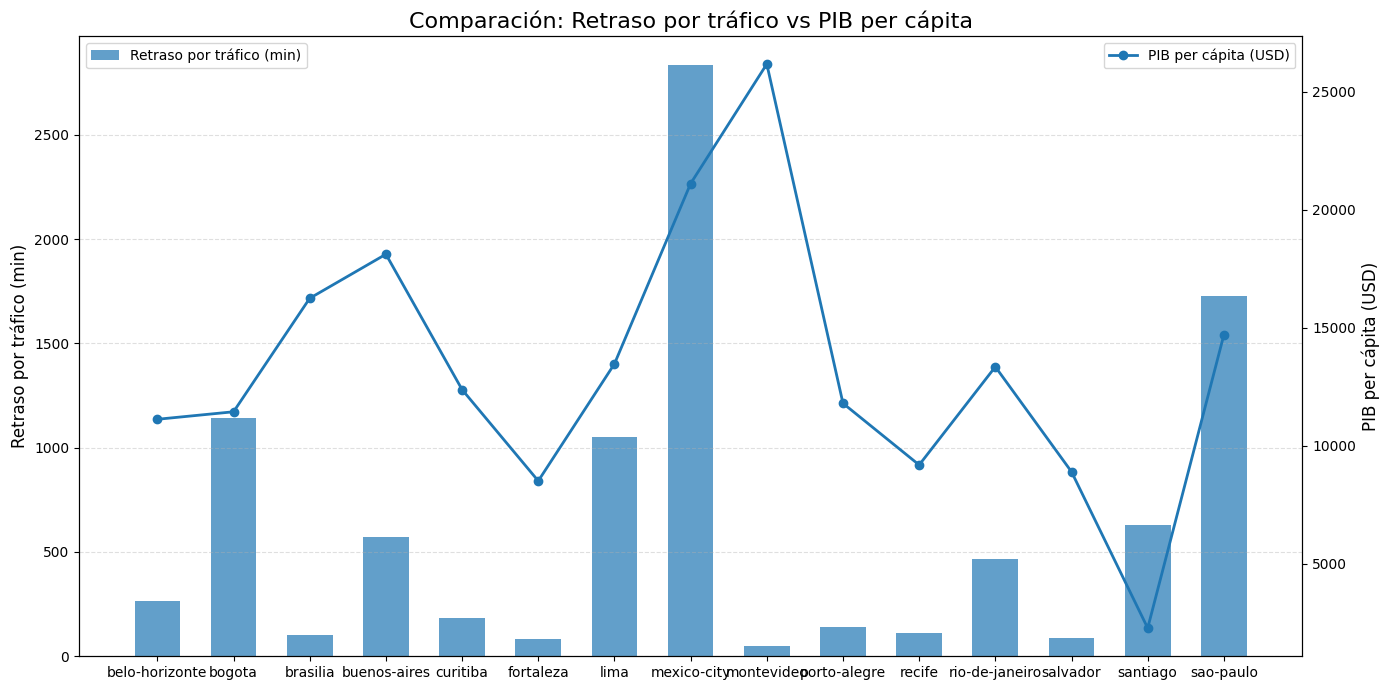

In [24]:
# ========================================
# VISUALIZACIÓN Y ANÁLISIS DE RELACIONES.
# ========================================

import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------
# BOXPlot - Distribución del tráfico (jams_delay)
# -------------------------------------------------

plt.figure(figsize=(12, 6))
sns.boxplot(data=merged, y="jams_delay", color="skyblue", showmeans=True)
plt.title("Distribución del Retraso por Tráfico (jams_delay)", fontsize=16)
plt.ylabel("Retraso por tráfico (min)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# ----------------------------------------------
# HISTOGRAMA - Distribución del PIB per cápita
# ----------------------------------------------

plt.figure(figsize=(12, 6))
sns.histplot(merged["gdp_per_capita"], kde=True, bins=10)
plt.title("Distribución del PIB per Cápita", fontsize=16)
plt.xlabel("PIB per cápita (USD)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# GRÁFICO COMBINADO - Congestión vs PIB per cápita
# --------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Barras para jams_delay ---
ax1.bar(merged["city"], merged["jams_delay"], alpha=0.7, width=0.6, label="Retraso por tráfico (min)")
ax1.set_ylabel("Retraso por tráfico (min)", fontsize=12)
ax1.tick_params(axis="y")

# --- Línea para gdp_per_capita ---
ax2 = ax1.twinx()
ax2.plot(merged["city"], merged["gdp_per_capita"], marker="o", linewidth=2, label="PIB per cápita (USD)")
ax2.set_ylabel("PIB per cápita (USD)", fontsize=12)
ax2.tick_params(axis="y")

# --- Mejoras visuales para el análisis ---
plt.title("Comparación: Retraso por tráfico vs PIB per cápita", fontsize=16)
plt.xticks(rotation=45, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# Leyendas
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Mostrar
plt.show()

## 8. Hallazgos principales

La comparación visual no muestra una relación lineal clara entre un mayor PIB per cápita y una mayor congestión. Algunas ciudades con niveles económicos elevados presentan retrasos importantes, mientras que otras mantienen niveles de congestión relativamente menores.

El comportamiento es heterogéneo entre ciudades, lo que sugiere que la movilidad urbana depende de múltiples factores además del nivel económico, como infraestructura, densidad, planificación urbana, transporte público y características demográficas.

Por ello, los resultados deben interpretarse como evidencia exploratoria y no como una relación causal entre congestión y productividad económica.


### Patrones observados

1. El boxplot muestra una alta variabilidad en los niveles de congestión y evidencia valores atípicos relevantes.
2. Algunas ciudades presentan retrasos por tráfico considerablemente superiores al resto del conjunto analizado.
3. La distribución del PIB per cápita es asimétrica: un grupo reducido de ciudades alcanza los niveles más altos.
4. La comparación visual entre PIB per cápita y congestión no muestra una relación proporcional directa, por lo que conviene complementar este análisis con métricas estadísticas y variables adicionales antes de establecer conclusiones causales.


## 9. Exportación del dataset analítico

El DataFrame integrado se exporta como `ladb_mobility_economy_2024_clean.csv`, generando una versión limpia y reutilizable para análisis posteriores.


In [25]:
# =========================
# EXPORTAR DATASET LIMPIO 
# =========================

merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

print("✅ Archivo exportado exitosamente:")
print("   ladb_mobility_economy_2024_clean.csv")

✅ Archivo exportado exitosamente:
   ladb_mobility_economy_2024_clean.csv


# 10. Resumen ejecutivo

### Contexto y objetivo

El proyecto evalúa la relación entre movilidad urbana y productividad económica mediante la integración de indicadores de tráfico y PIB per cápita. El propósito es identificar patrones que puedan apoyar la priorización de análisis e iniciativas relacionadas con infraestructura y transporte.

### Cobertura de datos

Los datos de tráfico de 2024 fueron agregados a nivel ciudad, obteniendo **387 registros ciudad-país-año** antes de la integración con la fuente económica. Después del `INNER JOIN` por `city` y `year`, el dataset analítico final contiene **15 ciudades** con información coincidente de movilidad y economía para 2024.

### Metodología

Se realizó exploración de datos, estandarización de nombres de columnas, conversión de fechas, normalización de formatos numéricos y creación de variables derivadas. Las métricas de tráfico se agregaron por ciudad y año y posteriormente se integraron con los indicadores económicos. Finalmente, se utilizaron boxplots, histogramas y una visualización comparativa para examinar distribuciones, valores atípicos y patrones generales.

### Hallazgos

En el conjunto de tráfico agregado, **Mexico City** registró el mayor `jams_delay` promedio de 2024, con aproximadamente **2,833.06**. En el dataset integrado se observa una variabilidad importante tanto en congestión como en PIB per cápita. La comparación visual no evidencia una relación lineal clara entre ambas variables, por lo que los resultados deben considerarse exploratorios.

### Recomendaciones

Se recomienda ampliar el análisis con medidas estadísticas de asociación, incorporar variables como densidad poblacional, cobertura de transporte público e inversión en infraestructura, y validar la comparabilidad de las fuentes antes de formular recomendaciones de inversión. Las ciudades con congestión elevada pueden utilizarse como punto de partida para análisis más detallados, evitando atribuir diferencias económicas únicamente al tráfico.


In [26]:
import os

# Verificar tamaño del archivo
file_size = os.path.getsize("ladb_mobility_economy_2024_clean.csv")

print(f"📁 Tamaño del archivo: {file_size} bytes")
print(f"📁 Tamaño en KB: {file_size / 1024:.2f} KB")
print(f"📁 Tamaño en MB: {file_size / (1024*1024):.2f} MB")

# También puedes verificar las dimensiones del DataFrame
print(f"\n📋 Dimensiones del dataset:")
print(f"   Filas: {merged.shape[0]}")
print(f"   Columnas: {merged.shape[1]}")

📁 Tamaño del archivo: 834 bytes
📁 Tamaño en KB: 0.81 KB
📁 Tamaño en MB: 0.00 MB

📋 Dimensiones del dataset:
   Filas: 15
   Columnas: 5
